# MNIST transfer purification — MPS vs JEM

This notebook compares MPS and JEM models in two combined grids: likelihood/score purification and Gibbs/SGLD purification. Columns are models, grouped under centred MPS and JEM headings; each digit occupies a compact three-row block (Clean, Adv., Purified), with the prediction shown below every image.

The clean examples are shared across every column. For every requested class, `EXAMPLE_SEED=None` chooses a new random test image on each run; set it to an integer to reproduce the selection. Example selection only requires PGD to break the two unprotected base models ($\alpha=0$), avoiding a bias towards examples that fool every defense. After selection, however, each displayed model receives its own white-box PGD perturbation and purifies that model-specific adversarial image. Choose the visible models with `DISPLAY_ALPHAS` and `SHOW_AT` in the first code cell. Run from the project root with the `bm4tc` environment; Gibbs at $k=10$ is deliberately expensive.

In [1]:
import sys
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import display

# This notebook lives in notebooks/; Jupyter's CWD is that folder. Walk up to the
# repo root (the dir containing src/) so all analysis/figures paths resolve.
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "src").is_dir() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))
print(f"PROJECT_ROOT = {PROJECT_ROOT}")


from analysis.visualize.mnist_transfer_purify import (
    _load_model as load_mps_model,
    _test_loader as mps_test_loader,
)
from baselines.jem.analysis import _load as load_jem_run
from baselines.jem.attacks import PGDConfig, pgd_classification
from baselines.jem.device import resolve_device
from baselines.jem.purification import (
    PurificationConfig as JEMPurificationConfig,
    gradient_purify,
    sgld_purify_snapshots,
)
from src.analysis.purification import GibbsPurification, LikelihoodPurification
from src.utils.embeddings import rel_to_abs
from src.utils.evasion import ProjectedGradientDescent

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "outputs").is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "outputs").is_dir():
    raise FileNotFoundError(f"Could not locate the project root from {Path.cwd()}")
os.chdir(PROJECT_ROOT)  # The model paths below are relative to the project root.
DEVICE = resolve_device("cuda:0" if torch.cuda.is_available() else "cpu")
# --- DISPLAY SELECTION ---------------------------------------------------------------
DISPLAY_ALPHAS = [0.0, 0.01, 0.1]  # choose among 0, .01, .1, .2, .5, 1
SHOW_AT = True
CLASSES = [3]
EXAMPLE_SEED = None  # None: new random images each run; use an integer to reproduce them
# Budgets are RELATIVE: fractions of the input-domain width (see CLAUDE.md).
# Both families are asserted onto the same input_range in the next cell, so one
# relative number is well defined for MPS and JEM alike; the absolute values are
# derived there, once. Both were 0.2 absolute before, which is the same budget.
ATTACK_EPS_REL = 0.1
PURIFY_DELTA_REL = 0.1
ATTACK_STEPS = 40
ATTACK_RESTARTS = 5
LIKELIHOOD_STEPS = 20
K = 10
MAX_ATTACK_SAMPLES = None  # search the full test set until every requested class is found
BATCH_SIZE = 128

OUTPUT_DIR = PROJECT_ROOT / "figures/transfer_purify"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ALPHA_KEYS = {0.0: "a0", 0.01: "a001", 0.1: "a01", 0.2: "a02", 0.5: "a05", 1.0: "a1"}
MPS_REGISTRY = {
    "a0":   (r"$\alpha=0$",    "outputs/mnist_full_r12/nat/legendre/d3r20c64/seed_sweep/a0_2406/0/models/model"),
    "a001": (r"$\alpha=0.01$", "outputs/mnist_full_r12/nat/legendre/d3r20c64/seed_sweep/a001_2007/0/models/model"),
    "a01":  (r"$\alpha=0.1$",  "outputs/mnist_full_r12/nat/legendre/d3r20c64/seed_sweep/a01_2107/0/models/model"),
    "a02":  (r"$\alpha=0.2$",  "outputs/mnist_full_r12/nat/legendre/d3r20c64/seed_sweep/a02_2107/0/models/model"),
    "a05":  (r"$\alpha=0.5$",  "outputs/mnist_full_r12/nat/legendre/d3r20c64/seed_sweep/a05_2107/0/models/model"),
    "a1":   (r"$\alpha=1$",    "outputs/mnist_full_r12/nat/legendre/d3r20c64/seed_sweep/a1_2107/0/models/model"),
    "at":   ("AT",             "outputs/mnist_full_r12/at/legendre/d3r20c64/seed_sweep/a0_2507/0/models/model"),
}
JEM_REGISTRY = {
    "a0":   (r"$\alpha=0$",    "outputs/baselines/jem/mnist_full_r12/nat/mlp_h550x480/seed_sweep/a0_2607/0"),
    "a001": (r"$\alpha=0.01$", "outputs/baselines/jem/mnist_full_r12/nat/mlp_h550x480/seed_sweep/a001_2607/0"),
    "a01":  (r"$\alpha=0.1$",  "outputs/baselines/jem/mnist_full_r12/nat/mlp_h550x480/seed_sweep/a01_2607/0"),
    "a02":  (r"$\alpha=0.2$",  "outputs/baselines/jem/mnist_full_r12/nat/mlp_h550x480/seed_sweep/a02_2607/0"),
    "a05":  (r"$\alpha=0.5$",  "outputs/baselines/jem/mnist_full_r12/nat/mlp_h550x480/seed_sweep/a05_2607/0"),
    "a1":   (r"$\alpha=1$",    "outputs/baselines/jem/mnist_full_r12/nat/mlp_h550x480/seed_sweep/a1_2607/0"),
    "at":   ("AT",             "outputs/baselines/jem/mnist_full_r12/at/mlp_h550x480/seed_sweep/at_2707/0"),
}
unknown = [alpha for alpha in DISPLAY_ALPHAS if alpha not in ALPHA_KEYS]
if unknown:
    raise ValueError(f"Unsupported DISPLAY_ALPHAS: {unknown}")
DISPLAY_KEYS = [ALPHA_KEYS[alpha] for alpha in DISPLAY_ALPHAS] + (["at"] if SHOW_AT else [])
LOAD_KEYS = list(dict.fromkeys(["a0", *DISPLAY_KEYS]))  # a0 is always needed as attack source
MPS_MODELS = [(key, *MPS_REGISTRY[key]) for key in LOAD_KEYS]
JEM_MODELS = [(key, *JEM_REGISTRY[key]) for key in LOAD_KEYS]
torch.manual_seed(0); np.random.seed(0)
print(f"device: {DEVICE}")

PROJECT_ROOT = /Users/jose/VSCodeProjects/bm4tc


INFO:baselines.jem.device:Using cpu


device: cpu


In [2]:
# Load every concrete checkpoint once and print the exact setup.
mps = {}
for key, label, path in MPS_MODELS:
    model, cfg, run_dir = load_mps_model(path, DEVICE)
    mps[key] = dict(label=label, model=model, cfg=cfg, run_dir=run_dir)

jem = {}
for key, label, path in JEM_MODELS:
    run_dir = Path(path)
    cfg, model, datahandler, sampler = load_jem_run(run_dir, DEVICE)
    model.eval()
    jem[key] = dict(label=label, model=model, cfg=cfg, run_dir=run_dir, datahandler=datahandler, sampler=sampler)

mps_lo, mps_hi = map(float, mps["a0"]["model"].input_range)
jem_lo, jem_hi = map(float, jem["a0"]["model"].input_range)
assert (mps_lo, mps_hi) == (jem_lo, jem_hi), "The shared comparison requires the same input range."
# Single conversion boundary -- every budget below this line is absolute.
ATTACK_EPS_ABS = rel_to_abs(ATTACK_EPS_REL, mps_hi - mps_lo)
PURIFY_DELTA_ABS = rel_to_abs(PURIFY_DELTA_REL, mps_hi - mps_lo)
# The Gibbs step stays relative and is passed through untouched. NOTE: it is a
# PER-SWEEP L-inf move and the window re-centres each sweep, so after K sweeps the
# coordinate envelope reaches K * PURIFY_DELTA_REL * (hi - lo) -- at K=10 and 0.1
# that is the entire domain. Tying the step to the purification radius is a
# deliberate choice here (one budget for every defense in the comparison), but it
# means the Gibbs column is far less restricted than the likelihood one.
print("MPS models")
for key, entry in mps.items():
    born = entry["cfg"].born
    print(f"  {key:4s} | run={entry['run_dir']} | {born.embedding} | d={born.init_kwargs.in_dim}, bond={born.init_kwargs.bond_dim}")
print("JEM models")
for key, entry in jem.items():
    print(f"  {key:4s} | run={entry['run_dir']} | JEMMLP | parameters={entry['model'].count_parameters():,}")
print("Purification / attack configuration")
print(f"  attack: PGD L∞, eps_rel={ATTACK_EPS_REL:.3f} (abs {ATTACK_EPS_ABS:.3f}), {ATTACK_STEPS} steps")
print(f"  MPS likelihood: L∞ delta_rel={PURIFY_DELTA_REL:.3f} (abs {PURIFY_DELTA_ABS:.3f}), {LIKELIHOOD_STEPS} steps")
print(f"  MPS Gibbs: k={K} sweeps, per-sweep step_delta_rel={PURIFY_DELTA_REL:.3f}"
      f" (envelope up to k x step = {K * PURIFY_DELTA_REL:.3f} of the range)")
print(f"  JEM score ascent: L∞ delta_abs={PURIFY_DELTA_ABS:.3f}, {LIKELIHOOD_STEPS} steps")
print(f"  JEM SGLD: k={K} sweeps × {JEMPurificationConfig().num_steps} transitions, local delta_abs={PURIFY_DELTA_ABS:.3f}")

INFO:analysis.utils.mia_utils:Reconstructed config for outputs/mnist_full_r12/nat/legendre/d3r20c64/seed_sweep/a0_2406/0 from /Users/jose/VSCodeProjects/bm4tc/configs/experiments/mnist_full_r12/nat/legendre/d3r20c64/seed_sweep/a0.yaml
INFO:src.model:[CBM] Cached log Z = 58.579002
INFO:analysis.visualize.mnist_transfer_purify:Loaded outputs/mnist_full_r12/nat/legendre/d3r20c64/seed_sweep/a0_2406/0
INFO:analysis.utils.mia_utils:Reconstructed config for outputs/mnist_full_r12/nat/legendre/d3r20c64/seed_sweep/a001_2007/0 from /Users/jose/VSCodeProjects/bm4tc/configs/experiments/mnist_full_r12/nat/legendre/d3r20c64/seed_sweep/a001.yaml
INFO:src.model:[CBM] Cached log Z = 106.815903
INFO:analysis.visualize.mnist_transfer_purify:Loaded outputs/mnist_full_r12/nat/legendre/d3r20c64/seed_sweep/a001_2007/0
INFO:analysis.utils.mia_utils:Reconstructed config for outputs/mnist_full_r12/nat/legendre/d3r20c64/seed_sweep/a01_2107/0 from /Users/jose/VSCodeProjects/bm4tc/configs/experiments/mnist_full_r1

MPS models
  a0   | run=outputs/mnist_full_r12/nat/legendre/d3r20c64/seed_sweep/a0_2406/0 | legendre | d=3, bond=20
  a001 | run=outputs/mnist_full_r12/nat/legendre/d3r20c64/seed_sweep/a001_2007/0 | legendre | d=3, bond=20
  a01  | run=outputs/mnist_full_r12/nat/legendre/d3r20c64/seed_sweep/a01_2107/0 | legendre | d=3, bond=20
  at   | run=outputs/mnist_full_r12/at/legendre/d3r20c64/seed_sweep/a0_2507/0 | legendre | d=3, bond=20
JEM models
  a0   | run=outputs/baselines/jem/mnist_full_r12/nat/mlp_h550x480/seed_sweep/a0_2607/0 | JEMMLP | parameters=349,040
  a001 | run=outputs/baselines/jem/mnist_full_r12/nat/mlp_h550x480/seed_sweep/a001_2607/0 | JEMMLP | parameters=349,040
  a01  | run=outputs/baselines/jem/mnist_full_r12/nat/mlp_h550x480/seed_sweep/a01_2607/0 | JEMMLP | parameters=349,040
  at   | run=outputs/baselines/jem/mnist_full_r12/at/mlp_h550x480/seed_sweep/at_2707/0 | JEMMLP | parameters=349,040
Purification / attack configuration
  attack: PGD L∞, eps=0.200 absolute, 40 steps

In [3]:
def predict_mps(model, x):
    with torch.no_grad():
        return model.class_probabilities(x.to(DEVICE)).argmax(1).cpu().numpy()

def predict_jem(model, x):
    with torch.no_grad():
        return model(x.to(DEVICE)).argmax(1).cpu().numpy()

def collect_base_attacks(loader):
    """Find shared clean digits for which PGD breaks both a0 models."""
    mps_source, jem_source = mps['a0']['model'], jem['a0']['model']
    generator = torch.Generator()
    if EXAMPLE_SEED is None:
        generator.seed()
    else:
        generator.manual_seed(EXAMPLE_SEED)
    random_order = torch.randperm(len(loader.dataset), generator=generator).tolist()
    randomized_dataset = torch.utils.data.Subset(loader.dataset, random_order)
    loader = torch.utils.data.DataLoader(
        randomized_dataset, batch_size=loader.batch_size, shuffle=False,
        num_workers=loader.num_workers, pin_memory=loader.pin_memory,
        collate_fn=loader.collate_fn,
    )
    mps_attack = ProjectedGradientDescent(
        norm='inf', num_steps=ATTACK_STEPS, random_start=True,
    )
    found, attacked = {}, 0
    for clean, labels in loader:
        if MAX_ATTACK_SAMPLES is not None and attacked >= MAX_ATTACK_SAMPLES:
            break
        if MAX_ATTACK_SAMPLES is not None:
            remaining = MAX_ATTACK_SAMPLES - attacked
            clean, labels = clean[:remaining], labels[:remaining]
        clean, labels = clean.to(DEVICE), labels.to(DEVICE)
        attacked += len(clean)
        y = labels.cpu().numpy()
        clean_ok = (predict_mps(mps_source, clean) == y) & (predict_jem(jem_source, clean) == y)
        for _ in range(ATTACK_RESTARTS):
            mps_adv = mps_attack.generate(mps_source, clean, labels, ATTACK_EPS_ABS, DEVICE)
            jem_adv = pgd_classification(
                jem_source, clean, labels,
                PGDConfig(epsilon=ATTACK_EPS_ABS, num_steps=ATTACK_STEPS),
            )
            success = clean_ok.copy()
            success &= predict_mps(mps_source, mps_adv) != y
            success &= predict_jem(jem_source, jem_adv) != y
            for class_idx in CLASSES:
                if class_idx in found:
                    continue
                hits = np.flatnonzero(success & (y == class_idx))
                if len(hits):
                    index = int(hits[0])
                    found[class_idx] = (
                        clean[index].cpu(), mps_adv[index].cpu(), jem_adv[index].cpu(),
                    )
            if len(found) == len(CLASSES):
                break
        if len(found) == len(CLASSES):
            break
    missing = [class_idx for class_idx in CLASSES if class_idx not in found]
    if missing:
        raise RuntimeError(
            f'No paired base-model attacks found for classes {missing} after '
            f'{attacked} test inputs and {ATTACK_RESTARTS} restarts.'
        )
    return {
        'clean': torch.stack([found[c][0] for c in CLASSES]),
        'labels': np.asarray(CLASSES),
        'adv': {
            ('MPS', 'a0'): torch.stack([found[c][1] for c in CLASSES]),
            ('JEM', 'a0'): torch.stack([found[c][2] for c in CLASSES]),
        },
    }

def generate_display_attacks(examples):
    """Generate a separate white-box PGD perturbation for every displayed model."""
    clean = examples['clean'].to(DEVICE)
    labels = torch.as_tensor(examples['labels'], device=DEVICE)
    mps_attack = ProjectedGradientDescent(
        norm='inf', num_steps=ATTACK_STEPS, random_start=True,
    )
    for key in DISPLAY_KEYS:
        if ('MPS', key) not in examples['adv']:
            examples['adv'][('MPS', key)] = mps_attack.generate(
                mps[key]['model'], clean, labels, ATTACK_EPS_ABS, DEVICE,
            ).cpu()
        if ('JEM', key) not in examples['adv']:
            examples['adv'][('JEM', key)] = pgd_classification(
                jem[key]['model'], clean, labels,
                PGDConfig(epsilon=ATTACK_EPS_ABS, num_steps=ATTACK_STEPS),
            ).cpu()

def display_comparison_grid(title, purification_label, examples, purified, output):
    """Columns are models; every digit occupies compact Clean/Adv./Purified rows."""
    columns = (
        [('MPS', key, mps[key], predict_mps) for key in DISPLAY_KEYS]
        + [('JEM', key, jem[key], predict_jem) for key in DISPLAY_KEYS]
    )
    n_mps, n_jem = len(DISPLAY_KEYS), len(DISPLAY_KEYS)
    family_gap = 1 if n_mps and n_jem else 0
    column_slots = list(range(n_mps)) + list(range(n_mps + family_gap, n_mps + family_gap + n_jem))
    width_ratios = [1.0] * n_mps + ([0.32] if family_gap else []) + [1.0] * n_jem
    row_slots, height_ratios, slot = [], [], 0
    for digit_index in range(len(CLASSES)):
        row_slots.append((slot, slot + 1, slot + 2))
        height_ratios.extend([1.0, 1.0, 1.0])
        slot += 3
        if digit_index < len(CLASSES) - 1:
            height_ratios.append(0.34)
            slot += 1
    figure = plt.figure(
        figsize=(1.5 * len(columns) + 1.0, 1.28 * 3 * len(CLASSES) + 0.45 * (len(CLASSES) - 1)),
    )
    grid = figure.add_gridspec(
        len(height_ratios), len(width_ratios),
        height_ratios=height_ratios, width_ratios=width_ratios,
        hspace=0.10, wspace=0.12,
    )
    axes = {}
    states = ('Clean', 'Adv.', f'Purified\n({purification_label})')
    for column_index, ((family, key, entry, predict), column_slot) in enumerate(zip(columns, column_slots)):
        model = entry['model']
        model_adv = examples['adv'][(family, key)]
        model_purified = purified[(family, key)]
        images_by_state = (examples['clean'], model_adv, model_purified)
        predictions_by_state = tuple(predict(model, images) for images in images_by_state)
        for digit_index, class_idx in enumerate(CLASSES):
            for state_index, row_slot in enumerate(row_slots[digit_index]):
                axis = figure.add_subplot(grid[row_slot, column_slot])
                axes[(digit_index, state_index, column_index)] = axis
                axis.set_xticks([]); axis.set_yticks([])
                image = images_by_state[state_index][digit_index]
                image = ((image.float() - mps_lo) / (mps_hi - mps_lo)).reshape(12, 12)
                axis.imshow(image, cmap='gray', vmin=0, vmax=1)
                axis.set_xlabel(
                    f'Pred. {int(predictions_by_state[state_index][digit_index])}',
                    fontsize=8, color='0.35', labelpad=1,
                )
                if column_index == 0:
                    prefix = f'Class {class_idx}\n' if state_index == 0 else ''
                    axis.set_ylabel(
                        prefix + states[state_index], rotation=0, ha='right', va='center',
                        fontsize=9, labelpad=38,
                    )
        axes[(0, 0, column_index)].set_title(entry['label'], fontsize=10, pad=10)
    figure.subplots_adjust(left=0.14, right=0.99, bottom=0.04, top=0.87)
    figure.canvas.draw()
    for family, start, stop in (('MPS', 0, n_mps), ('JEM', n_mps, n_mps + n_jem)):
        if stop <= start:
            continue
        left = axes[(0, 0, start)].get_position().x0
        right = axes[(0, 0, stop - 1)].get_position().x1
        figure.text((left + right) / 2, 0.93, family, ha='center', va='center', fontsize=12, fontweight='bold')
    figure.suptitle(title, y=0.985, fontsize=13)
    figure.savefig(output, dpi=300, bbox_inches='tight')
    display(figure)
    plt.close(figure)

def mps_likelihood(model, data):
    return LikelihoodPurification(norm='inf', num_steps=LIKELIHOOD_STEPS).purify(model, data, PURIFY_DELTA_ABS, DEVICE)[0].cpu()

def mps_gibbs(model, data):
    return GibbsPurification(num_bins=20, gibbs_batch_size=8, step_delta_rel=PURIFY_DELTA_REL).purify(model, data, K, DEVICE)[0].cpu()

def jem_score(model, data):
    return gradient_purify(model, data.to(DEVICE), JEMPurificationConfig(radius=PURIFY_DELTA_ABS, num_steps=LIKELIHOOD_STEPS)).cpu()

def jem_sgld(entry, data):
    cfg = JEMPurificationConfig(radius=PURIFY_DELTA_ABS, num_steps=20, step_size=0.01, sgld_noise_std=0.005)
    return sgld_purify_snapshots(entry['model'], entry['sampler'], data.to(DEVICE), cfg, (K,))[K].cpu()

In [4]:
# Select shared clean digits, then create a separate attack for every model column.
base_loader = mps_test_loader(mps['a0']['cfg'], mps['a0']['model'], BATCH_SIZE)
examples = collect_base_attacks(base_loader)
generate_display_attacks(examples)
print(f"Selected classes: {examples['labels'].tolist()}")

INFO:src.datahandler:MNIST loaded: 70000 samples, 144 features
INFO:src.datahandler:Generated dataset 'mnist_full' and saved to /Users/jose/VSCodeProjects/bm4tc/.datasets/mnist/mnist_full_r12.npz


Selected classes: [3]


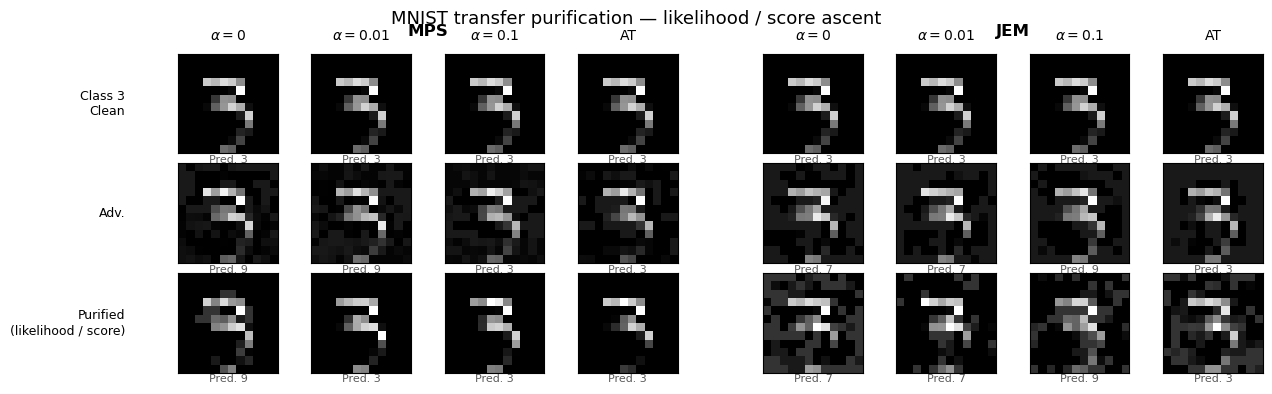

In [5]:
# Combined MPS/JEM likelihood/score purification figure.
likelihood_purified = {}
for key in DISPLAY_KEYS:
    likelihood_purified[('MPS', key)] = mps_likelihood(mps[key]['model'], examples['adv'][('MPS', key)])
    likelihood_purified[('JEM', key)] = jem_score(jem[key]['model'], examples['adv'][('JEM', key)])

display_comparison_grid(
    'MNIST transfer purification — likelihood / score ascent',
    'likelihood / score',
    examples,
    likelihood_purified,
    OUTPUT_DIR / 'transfer_purify_mps_jem_likelihood_grid.pdf',
)

Gibbs:   0%|          | 0/1 [00:00<?, ?batch/s]

sweep 1/10:   0%|          | 0/144 [00:00<?, ?feat/s]

sweep 2/10:   0%|          | 0/144 [00:00<?, ?feat/s]

sweep 3/10:   0%|          | 0/144 [00:00<?, ?feat/s]

sweep 4/10:   0%|          | 0/144 [00:00<?, ?feat/s]

...

sweep 7/10:   0%|          | 0/144 [00:00<?, ?feat/s]

sweep 8/10:   0%|          | 0/144 [00:00<?, ?feat/s]

sweep 9/10:   0%|          | 0/144 [00:00<?, ?feat/s]

sweep 10/10:   0%|          | 0/144 [00:00<?, ?feat/s]

Gibbs log p(x):   0%|          | 0/1 [00:00<?, ?batch/s]

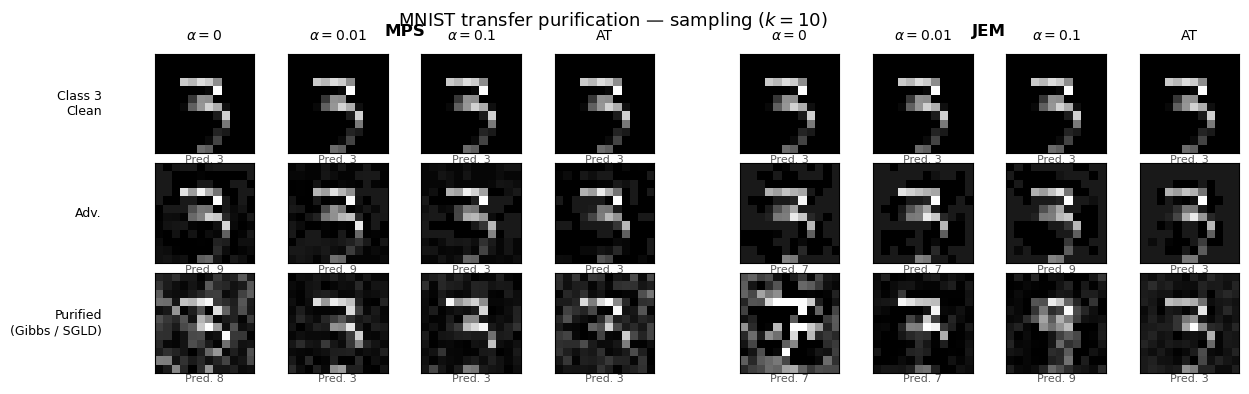

In [6]:
# Combined MPS/JEM Gibbs/SGLD purification figure.
sampling_purified = {}
for key in DISPLAY_KEYS:
    sampling_purified[('MPS', key)] = mps_gibbs(mps[key]['model'], examples['adv'][('MPS', key)])
    sampling_purified[('JEM', key)] = jem_sgld(jem[key], examples['adv'][('JEM', key)])

display_comparison_grid(
    f'MNIST transfer purification — sampling ($k={K}$)',
    'Gibbs / SGLD',
    examples,
    sampling_purified,
    OUTPUT_DIR / f'transfer_purify_mps_jem_sampling_k{K}_grid.pdf',
)

In [7]:
print(f"Saved combined figures to {OUTPUT_DIR}")

Saved combined figures to /Users/jose/VSCodeProjects/bm4tc/figures/transfer_purify
